# Import All Needed Libraries

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb
import matplotlib.pyplot as plt
import joblib

In [29]:


# Load data
df = pd.read_csv('data/smokes.csv')

# Prepare features and target
X = df[['Air Inhaled', 'Nicotine Concentration', 'Total Nicotine Inhaled']]
y = df['Target']

# Identify categorical and numerical columns
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object", "string", "category"]).columns.tolist()

print(f"Categorical columns: {cat_cols if cat_cols else 'None'}")
print(f"Numerical columns: {num_cols}")

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols)
    ]
)

# Create full pipeline with XGBoost Regressor
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", xgb.XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    ))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=True,
    random_state=42
)

# Fit model
model.fit(X_train, y_train)

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Saves the model
joblib.dump(model, 'nicotine_calculator_model.pkl')
print("Model saved as 'nicotine_calculator_model.pkl'")


Categorical columns: None
Numerical columns: ['Air Inhaled', 'Nicotine Concentration', 'Total Nicotine Inhaled']
Model saved as 'nicotine_calculator_model.pkl'


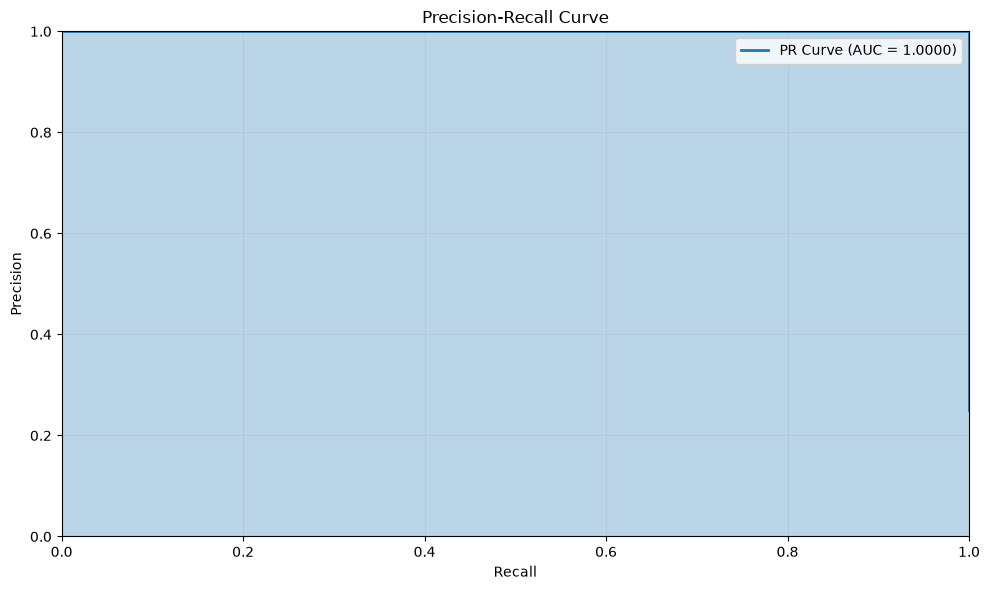

AUPRC (Area Under Precision-Recall Curve): 1.0000
Positive rate: 0.465


In [30]:
# For regression, create binary targets based on threshold
threshold = 0.5
y_test_binary = (y_test >= threshold).astype(int)  # Binary classification
y_pred_proba = y_pred_test  # Use predictions as scores

# Calculate PR curve
precision, recall, thresholds_pr = precision_recall_curve(y_test_binary, y_pred_proba)
pr_auc = auc(recall, precision)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, linewidth=2, label=f'PR Curve (AUC = {pr_auc:.4f})')
plt.fill_between(recall, precision, alpha=0.3)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

print(f"AUPRC (Area Under Precision-Recall Curve): {pr_auc:.4f}")
print("Positive rate:", y_test.mean())

In [31]:
from sklearn.metrics import precision_score, recall_score

for threshold in [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
    pred = (y_pred_proba >= threshold).astype(int)

    print(
        f"{threshold:.2f} | "
        f"signals={pred.sum():4d} | "
        f"precision={precision_score(y_test_binary, pred):.3f} | "
        f"recall={recall_score(y_test_binary, pred):.3f}"
    )

0.50 | signals=   1 | precision=1.000 | recall=1.000
0.55 | signals=   1 | precision=1.000 | recall=1.000
0.60 | signals=   1 | precision=1.000 | recall=1.000
0.65 | signals=   1 | precision=1.000 | recall=1.000
0.70 | signals=   1 | precision=1.000 | recall=1.000
0.75 | signals=   1 | precision=1.000 | recall=1.000
0.80 | signals=   0 | precision=0.000 | recall=0.000


c:\projects\NicotineCalculator\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [32]:
from sklearn.metrics import precision_score, recall_score

# Test best found thresholds on test set
for name, threshold in [("Conservative", 0.70)]:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    print(f"\n=== {name} (threshold={threshold:.4f}) ===")
    print(f"High Risk Cases Flagged: {y_pred_threshold.sum()}")
    print(f"Precision: {precision_score(y_test_binary, y_pred_threshold):.4f}")
    print(f"Recall: {recall_score(y_test_binary, y_pred_threshold):.4f}")

    # True Positives / False Positives
    tp = ((y_pred_threshold == 1) & (y_test_binary == 1)).sum()
    fp = ((y_pred_threshold == 1) & (y_test_binary == 0)).sum()

    print(f"True Positives (Correctly Flagged): {tp}, False Positives: {fp}")

    # Get actual risk scores for the selected cases
    test_targets = df.loc[y_test.index, "Target"]
    selected_targets = test_targets[y_pred_threshold == 1]

    print(f"Total risk score sum: {selected_targets.sum():.2f}")
    print(f"Average risk score: {selected_targets.mean():.4f}")
    print(f"Median risk score: {selected_targets.median():.4f}")


=== Conservative (threshold=0.7000) ===
High Risk Cases Flagged: 1
Precision: 1.0000
Recall: 1.0000
True Positives (Correctly Flagged): 1, False Positives: 0
Total risk score sum: 0.92
Average risk score: 0.9200
Median risk score: 0.9200
